# 금융 거래 고객 신용 위험 예측
- 금융 거래 데이터를 분석하여 고객 신용 위험을 예측하는 분류 모델 설계

데이터 출처 :  
(원본) https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data  
(정제) https://www.kaggle.com/datasets/adityapotdar23/german-credit-data?resource=download


- 목차
1. 데이터 읽기
2. EDA 및 데이터 정제
3. 데이터 시각화
4. 머신러닝 모델에 학습하기 위한 데이터 전처리
5. 모델 학습 및 평가
6. 예측 수행
7. 불균형 Class 데이터 처리

In [243]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder


from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier


from sklearn.metrics import accuracy_score, confusion_matrix, precision_score,recall_score,f1_score,classification_report

SEED = 42

sns.set_theme(style='whitegrid')

#한글 폰트 설정 (Mac은 AppleGothic)
plt.rcParams["font.family"] = "Malgun Gothic"

#마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

### 1. 데이터 불러오기

In [244]:
df_origin = pd.read_csv("data/german_credit_data.csv", index_col=0) # 첫번째 열은 인덱스로 사용
df_origin.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [245]:
# 데이터 크기 확인
df_origin.shape

(1000, 10)


- Age: 나이
- Sex: 성별
- Job: 직업 (직업 숙련도 정도로 볼 수 있습니다.)
    - 0: 비숙련직 및 비거주자 (unskilled and non-residnet)
    - 1: 비숙련직 및 거주자 (unskilled and resident)
    - 2: 숙련직 (skilled)
    - 3: 전문직 (highly skilled)
- Housing: 주거 형태
    - own: 자가
    - rent: 임대
    - free: (정확하지 않음) 정부나 기타 기관에서 지원해주는 주거 형태
- Saving accounts: 저축 예금의 잔고 정도
- Checking account: 당좌 예금의 잔고 정도
- Credit amount: 예금 보유량 (독일 마르크 기준)
- Duration: (정확하지 않음) 은행에 예금을 보유한 기간 (월단위)
- Purpose: 예금 보유 목적 (특정 물품 구매, 교육용, 휴가용 등등)

In [246]:
df_origin.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


### 2. 데이터 정제
- 결측값과 이상치 데이터 처리

In [247]:
df_origin.isna().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [248]:
# 결측치 있는 열의 고유값 확인
df_origin['Saving accounts'].unique()

<StringArray>
[nan, 'little', 'quite rich', 'rich', 'moderate']
Length: 5, dtype: str

In [249]:
df_origin['Checking account'].unique()

<StringArray>
['little', 'moderate', nan, 'rich']
Length: 4, dtype: str

In [250]:
df_clean = df_origin.copy()
df_clean    

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,40,male,3,own,little,little,3857,30,car,good
997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [251]:
# Saving account, Checking account 특성의 결측치를 'Others' 로 채운다.

df_clean['Saving accounts'] = df_clean['Saving accounts'].fillna('Others')
df_clean['Checking account'] = df_clean['Checking account'].fillna('Others')

df_clean.isna().sum()


Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

### 3. 데이터 시각화
- 변수별 상관관계를 시각화해서 확인한다

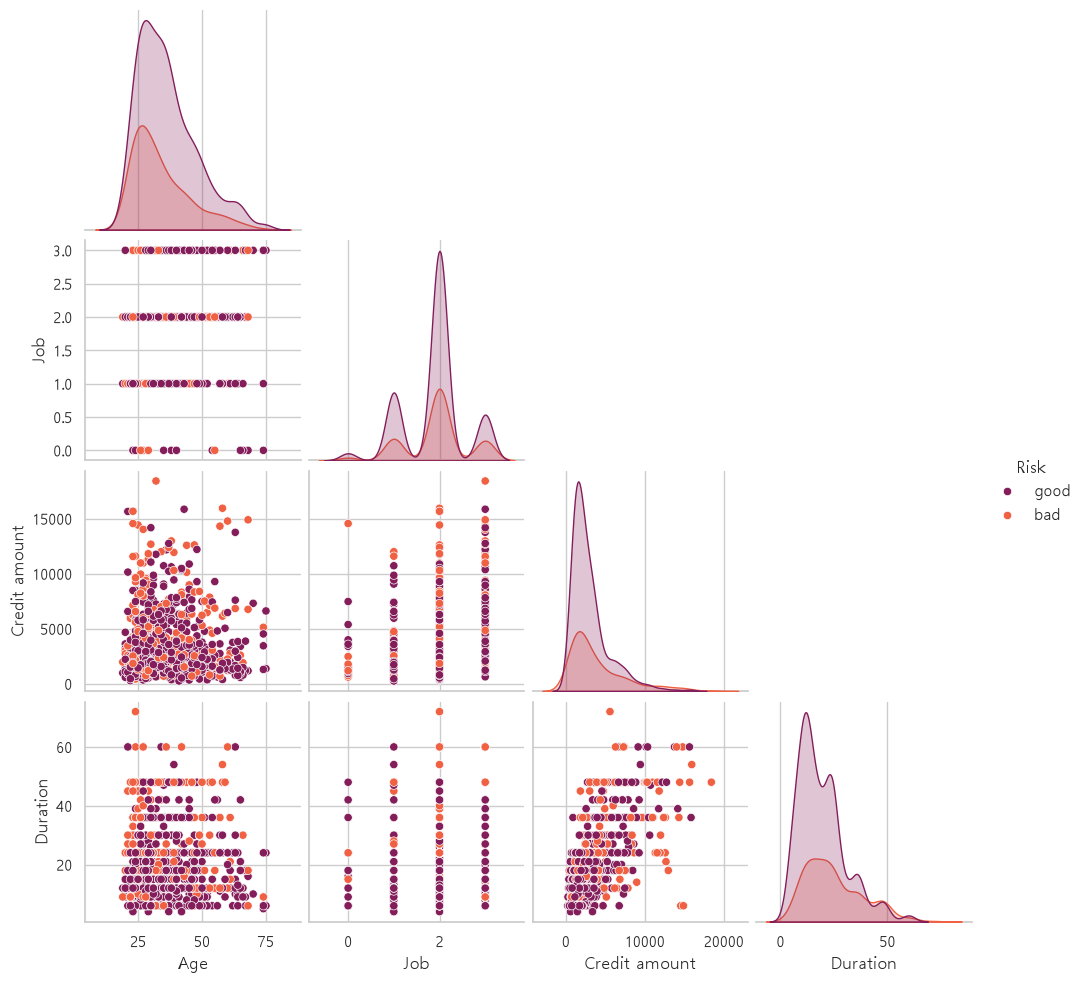

In [252]:
# pairplot : 주요 수치형 변수의 관계/ 분포를 hue(Risk)의 색상별로 확인
sns.pairplot(
    df_clean,
    vars= ['Age','Job','Credit amount', 'Duration'],    # 비교할 변수
    hue='Risk',         # 색상구분
    palette= 'rocket',  
    corner= True        # 중복되는 그래프 생략
)

plt.show()

Credit amount 와 Duration  : 약한 양의 상관관계  
Job 과 Credit amount       : 약한 양의 상관관계

<Axes: xlabel='Age', ylabel='Percent'>

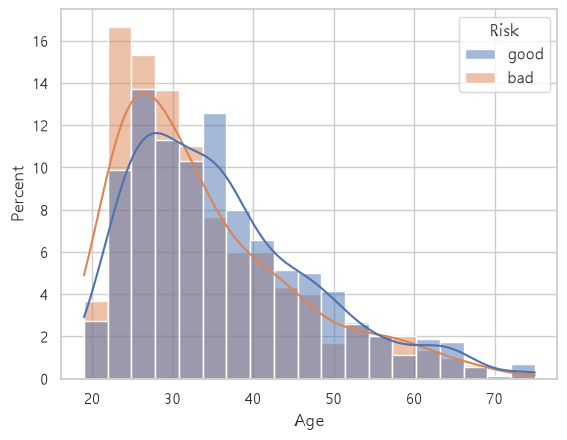

In [253]:
# 분포 확인용 히스토그램(비율로 표시, 그룹별 독립 정규화)
sns.histplot(df_clean,
             x="Age",
             hue='Risk', 
             kde= True,             # kde 곡선
             stat= 'percent',       # % 로 구분
             common_norm= False)    # 그룹별 정규화 하겠나

저연령대에서 저신용자가 많고, 30대 중반정도 이후부터 신용도가 좋은 비율이 많음

<Axes: xlabel='Sex', ylabel='Percent'>

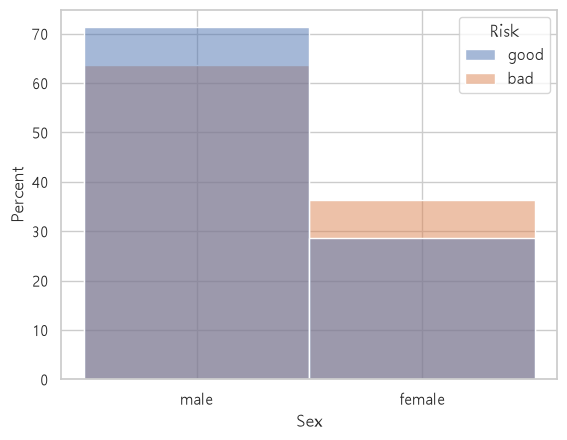

In [254]:
sns.histplot(df_clean,
             x="Sex",
             hue='Risk',          
             stat= 'percent',       
             common_norm= False)  

<Axes: xlabel='Job', ylabel='Percent'>

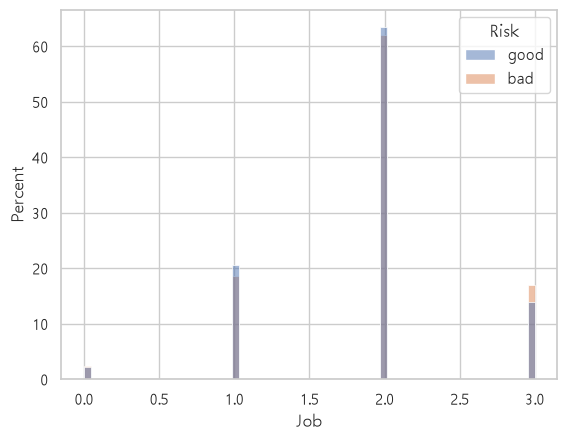

In [255]:
sns.histplot(df_clean,
             x="Job",
             hue='Risk',          
             stat= 'percent',       
             common_norm= False)  

# - Job: 직업 (직업 숙련도 정도로 볼 수 있습니다.)
#     - 0: 비숙련직 및 비거주자 (unskilled and non-residnet)
#     - 1: 비숙련직 및 거주자 (unskilled and resident)
#     - 2: 숙련직 (skilled)
#     - 3: 전문직 (highly skilled)

숙련직은 신용도가 좋고, 전문직은 다소 떨어지는 경향이 있다.

<Axes: xlabel='Housing', ylabel='Percent'>

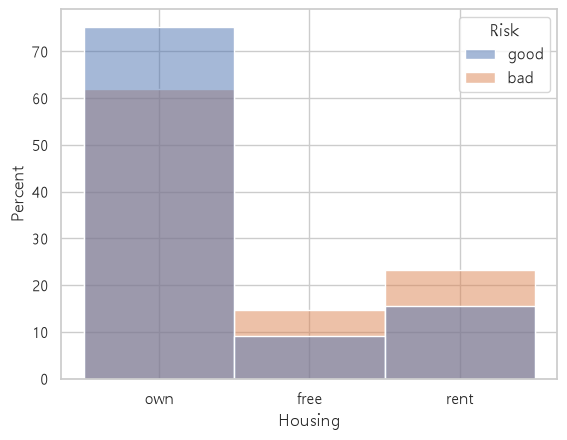

In [256]:
sns.histplot(df_clean,
             x="Housing",
             hue='Risk',          
             stat= 'percent',       
             common_norm= False)  


자가가 신용도가 좋다

<Axes: xlabel='Checking account', ylabel='Percent'>

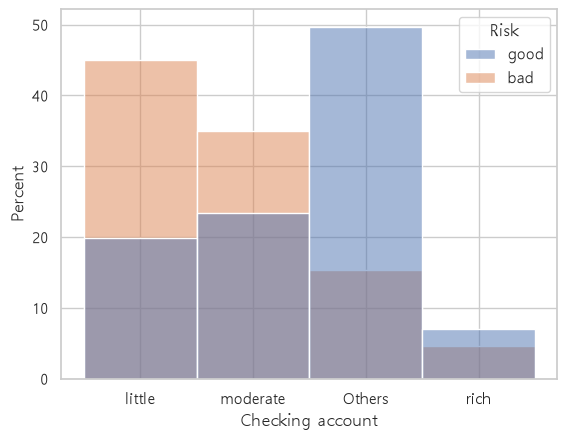

In [257]:
sns.histplot(df_clean,
             x="Checking account",
             hue='Risk',          
             stat= 'percent',       
             common_norm= False)  


<Axes: xlabel='Saving accounts', ylabel='Percent'>

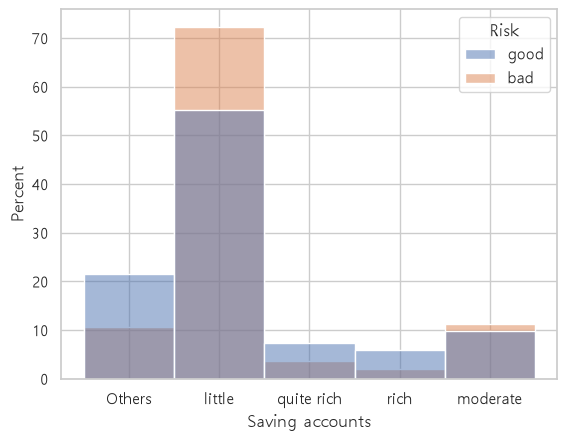

In [258]:
sns.histplot(df_clean,
             x="Saving accounts",
             hue='Risk',          
             stat= 'percent',       
             common_norm= False)  


저축예금이 많으면 신용도가 좋다

<Axes: xlabel='Credit amount', ylabel='Percent'>

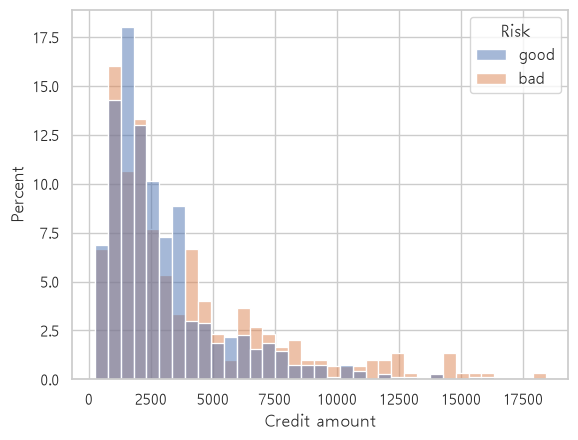

In [259]:
sns.histplot(df_clean,
             x="Credit amount",
             hue='Risk',          
             stat= 'percent',       
             common_norm= False)  


현금 보유량이 많을수록 위험도가 높은 사람의 비율이 높다

<Axes: xlabel='Duration', ylabel='Percent'>

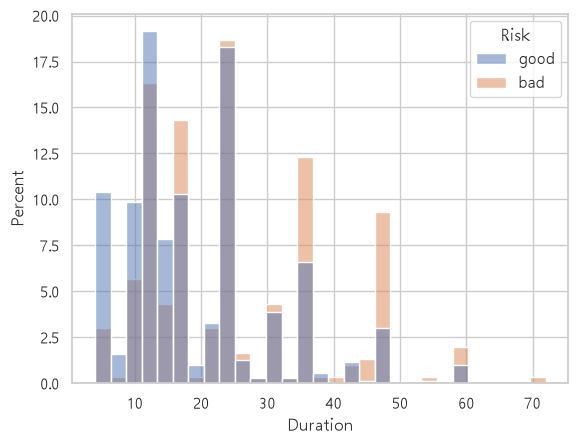

In [260]:
sns.histplot(df_clean,
             x="Duration",
             hue='Risk',          
             stat= 'percent',       
             common_norm= False)  

In [261]:
df_clean.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'radio/TV'),
  Text(1, 0, 'education'),
  Text(2, 0, 'furniture/equipment'),
  Text(3, 0, 'car'),
  Text(4, 0, 'business'),
  Text(5, 0, 'domestic appliances'),
  Text(6, 0, 'repairs'),
  Text(7, 0, 'vacation/others')])

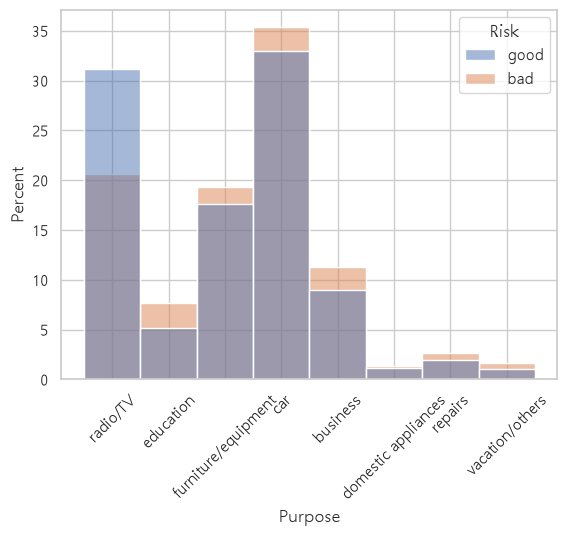

In [262]:
sns.histplot(df_clean,
             x="Purpose",
             hue='Risk',          
             stat= 'percent',       
             common_norm= False)  
plt.xticks(rotation=45)

신용 위험도가 낮은 사람들은 생활용품구매를 위해 예금하는 경향 있다

### 4. 데이터 전처리
- 카테고리형 변수를 수치형 변수로 변환
- 학습 데이터와 테스트 데이터 나누기
- 정규화 : 입력 변수들 값의 크기 범위를 조정

4-1. 수치형 변수 변환

In [263]:
df_origin['Saving accounts'].unique()

<StringArray>
[nan, 'little', 'quite rich', 'rich', 'moderate']
Length: 5, dtype: str

In [264]:
# OrdinalEncoder : 순서가 있는 범주형 인코딩에 주로 사용
ord_encoder = OrdinalEncoder(dtype=np.int32)

non_numeric_features = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']


# 순서를 직접 정하는 방식
# 순서를 명시한 리스트를 categories 에 지정하면 순서대로 번호를 매겨 반환
# saving_accounts_order = ['Other', 'little',  'moderate', 'quite rich', 'rich']
# saving_encoder= OrdinalEncoder(categories=[saving_accounts_order],dtype= np.int)
# df_clean['Saving accounts'] = saving_encoder.fit_transform(df_clean['Saving accounts'])

# ord_encoder, fit_transform()
df_clean[non_numeric_features] = ord_encoder.fit_transform(df_clean[non_numeric_features])

df_clean

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,1,0,1,1169,6,5,good
1,22,0,2,1,1,2,5951,48,5,bad
2,49,1,1,1,1,0,2096,12,3,good
3,45,1,2,0,1,1,7882,42,4,good
4,53,1,2,0,1,1,4870,24,1,bad
...,...,...,...,...,...,...,...,...,...,...
995,31,0,1,1,1,0,1736,12,4,good
996,40,1,3,1,1,1,3857,30,1,good
997,38,1,2,1,1,0,804,12,5,good
998,23,1,2,0,1,1,1845,45,5,bad


In [265]:
ord_encoder.categories_     # 변경 전 원래의 값 확인

[array(['female', 'male'], dtype=object),
 array(['free', 'own', 'rent'], dtype=object),
 array(['Others', 'little', 'moderate', 'quite rich', 'rich'], dtype=object),
 array(['Others', 'little', 'moderate', 'rich'], dtype=object),
 array(['business', 'car', 'domestic appliances', 'education',
        'furniture/equipment', 'radio/TV', 'repairs', 'vacation/others'],
       dtype=object)]

In [266]:
df_clean

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,1,0,1,1169,6,5,good
1,22,0,2,1,1,2,5951,48,5,bad
2,49,1,1,1,1,0,2096,12,3,good
3,45,1,2,0,1,1,7882,42,4,good
4,53,1,2,0,1,1,4870,24,1,bad
...,...,...,...,...,...,...,...,...,...,...
995,31,0,1,1,1,0,1736,12,4,good
996,40,1,3,1,1,1,3857,30,1,good
997,38,1,2,1,1,0,804,12,5,good
998,23,1,2,0,1,1,1845,45,5,bad


In [267]:
# Risk 변수 good -> 0 , bad -> 1 로 변환 map(dick)

df_clean['Risk'] = df_clean['Risk'].map({"good" : 0 , "bad"  : 1})
df_clean

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,1,0,1,1169,6,5,0
1,22,0,2,1,1,2,5951,48,5,1
2,49,1,1,1,1,0,2096,12,3,0
3,45,1,2,0,1,1,7882,42,4,0
4,53,1,2,0,1,1,4870,24,1,1
...,...,...,...,...,...,...,...,...,...,...
995,31,0,1,1,1,0,1736,12,4,0
996,40,1,3,1,1,1,3857,30,1,0
997,38,1,2,1,1,0,804,12,5,0
998,23,1,2,0,1,1,1845,45,5,1


4-2. 학습, 테스트 데이터 분리

In [268]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   int32
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   int32
 4   Saving accounts   1000 non-null   int32
 5   Checking account  1000 non-null   int32
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   int32
 9   Risk              1000 non-null   int64
dtypes: int32(5), int64(5)
memory usage: 58.7 KB


In [269]:
# 전체 데이터에서 입력값을 만들기
X = df_clean.drop('Risk', axis= 1)
y = df_clean["Risk"]

In [270]:
# 타겟 변수의 고유값별 개수
df_clean['Risk'].value_counts()     # 7:3 비율 (stratify = y 라서 train, test가 7:3 으로 분배됨)


Risk
0    700
1    300
Name: count, dtype: int64

In [271]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size= 0.2,
    random_state= SEED,
    stratify= y     # target 의 비율을 테스트/ 학습 데이터에서 비슷하게 유지 (위에서 확인한 7:3 비율)
)

print(len(X_train),len(X_test),len(y_train),len(y_test))

800 200 800 200


4-3. 정규화 진행

In [272]:
df_origin.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   str  
 4   Saving accounts   817 non-null    str  
 5   Checking account  606 non-null    str  
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
 9   Risk              1000 non-null   str  
dtypes: int64(4), str(6)
memory usage: 78.3 KB


In [273]:
# MinMaxScaler() : 모든 특성값을 0~1 사이로 정규화 해주는 스케일러
scaler = MinMaxScaler()

feature_names= X.columns.tolist()      # X 의 컬럼들을 리스트 형태로 뽑음(tolist())

numeric_features = ['Age', 'Credit amount', 'Duration']

# 학습데이터를 기준으로 학습하고,  변환한다.
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features]) 

# 테스트 데이터는 학습데이터 기준으로 (최소값/최대값) 만 변환
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

### 5. 모델 학습 및 평가
- LogisticRegression
- Naive Bayes
- Support Vector Machine
- DecisionTree / RandomForest
- XGBoost
- SoftVoting 앙상블

5-1. LogisticRegression

In [274]:
lr_model = LogisticRegression(random_state=42)

# 학습
lr_model.fit(X_train, y_train)
print('학습완료')

학습완료


In [275]:
# 각종 평가지표들을 한번에 출력해서 확인하고 반환받는 함수
def check_metrix(model, modle_name, X_train, X_test, y_train, y_test):
    y_pred_train =  model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # zero_division= 0 : 특정 클래스를 하나도 예측하지 못한 경우, 경고 대신에 0점으로 처리
    # pos_label= 1 : 위험 고객을 얼마나 잘 맞췄는지를 기준으로 계산
    acc_train = accuracy_score(y_train, y_pred_train)
    precision_train = precision_score(y_train, y_pred_train, zero_division=0)
    recall_train = recall_score(y_train, y_pred_train, zero_division=0)
    f1_train = f1_score(y_train, y_pred_train, zero_division=0, pos_label= 1)
    
    acc_test = accuracy_score(y_test, y_pred_test)
    precision_test = precision_score(y_test, y_pred_test, zero_division=0)
    recall_test = recall_score(y_test, y_pred_test, zero_division=0)
    f1_test = f1_score(y_test, y_pred_test, zero_division=0, pos_label= 1)
    
    
    print(f'{modle_name}의 학습 정확도 : {acc_train:.4f}')
    print(f'{modle_name}의 학습 정밀도 : {precision_train:.4f}')
    print(f'{modle_name}의 학습 재현율 : {recall_train:.4f}')
    print(f'{modle_name}의 학습 F1스코어 : {f1_train:.4f}')
    print('---'*30)
    print(f'{modle_name}의 학습 정확도 : {acc_test:.4f}')
    print(f'{modle_name}의 학습 정밀도 : {precision_test:.4f}')
    print(f'{modle_name}의 학습 재현율 : {recall_test:.4f}')
    print(f'{modle_name}의 학습 F1스코어 : {f1_test:.4f}')
    
    return{
        'model' : modle_name,
        'accuracy' : acc_test,
        'precision' : precision_test,
        'recall' : recall_test,
        'f1_score' : f1_test
    }
    
    
# 혼동행렬을 계산하고 시각화 하는 함수
def plot_confusion_matrix(model, model_name, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, 
                annot=True,     # 값표시
                fmt= 'd',       # 숫자 
                cmap= 'Blues', 
                xticklabels=['good(0)',"bad(1)"], 
                yticklabels=['good(0)',"bad(1)"]
                )
    
    
    plt.xlabel("예측값")
    plt.ylabel('실제값')
    plt.title(f"{model_name}의 혼동 행렬")
    plt.show()

In [276]:
model_result = []   # 모델별 테스트 성능 결과 저장

In [277]:
result = check_metrix(lr_model, "LogisticRegression", X_train,X_test,y_train,y_test)

model_result.append(result)

LogisticRegression의 학습 정확도 : 0.7000
LogisticRegression의 학습 정밀도 : 0.5000
LogisticRegression의 학습 재현율 : 0.1583
LogisticRegression의 학습 F1스코어 : 0.2405
------------------------------------------------------------------------------------------
LogisticRegression의 학습 정확도 : 0.7300
LogisticRegression의 학습 정밀도 : 0.6500
LogisticRegression의 학습 재현율 : 0.2167
LogisticRegression의 학습 F1스코어 : 0.3250


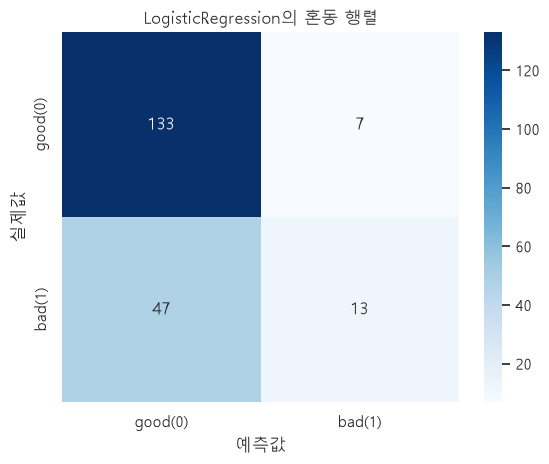

In [278]:
plot_confusion_matrix(lr_model,"LogisticRegression", X_test, y_test)

5-2. Naive Bayes

In [279]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

result = check_metrix(nb_model, "Naive Bayes", X_train,X_test,y_train,y_test)

model_result.append(result)

Naive Bayes의 학습 정확도 : 0.7125
Naive Bayes의 학습 정밀도 : 0.5347
Naive Bayes의 학습 재현율 : 0.3208
Naive Bayes의 학습 F1스코어 : 0.4010
------------------------------------------------------------------------------------------
Naive Bayes의 학습 정확도 : 0.7400
Naive Bayes의 학습 정밀도 : 0.5952
Naive Bayes의 학습 재현율 : 0.4167
Naive Bayes의 학습 F1스코어 : 0.4902


로지스틱 회귀보다 낫긴 하지만, 성능은 과소적합

5-3. Support Vector Machine (SVM)

In [280]:
svm_model = SVC(random_state=SEED, C= 10)

svm_model.fit(X_train, y_train)

result = check_metrix(svm_model, "SVM", X_train,X_test,y_train,y_test)

model_result.append(result)

SVM의 학습 정확도 : 0.7837
SVM의 학습 정밀도 : 0.7557
SVM의 학습 재현율 : 0.4125
SVM의 학습 F1스코어 : 0.5337
------------------------------------------------------------------------------------------
SVM의 학습 정확도 : 0.7600
SVM의 학습 정밀도 : 0.7000
SVM의 학습 재현율 : 0.3500
SVM의 학습 F1스코어 : 0.4667


5-4. DecisionTree 

In [281]:
dt_model = DecisionTreeClassifier(random_state=SEED)

dt_model.fit(X_train, y_train)

result = check_metrix(dt_model, "DecisionTree", X_train,X_test,y_train,y_test)

model_result.append(result)

DecisionTree의 학습 정확도 : 1.0000
DecisionTree의 학습 정밀도 : 1.0000
DecisionTree의 학습 재현율 : 1.0000
DecisionTree의 학습 F1스코어 : 1.0000
------------------------------------------------------------------------------------------
DecisionTree의 학습 정확도 : 0.7000
DecisionTree의 학습 정밀도 : 0.5000
DecisionTree의 학습 재현율 : 0.4500
DecisionTree의 학습 F1스코어 : 0.4737


DecisionTree 는 Max_depth 가 없으면 과적합 가능성이 높다

5-5. RandomForest

In [282]:
rf_model = RandomForestClassifier(random_state=SEED, max_depth=8)

rf_model.fit(X_train, y_train)

result = check_metrix(rf_model, "RandomForest", X_train,X_test,y_train,y_test)

model_result.append(result)

RandomForest의 학습 정확도 : 0.9125
RandomForest의 학습 정밀도 : 0.9521
RandomForest의 학습 재현율 : 0.7458
RandomForest의 학습 F1스코어 : 0.8364
------------------------------------------------------------------------------------------
RandomForest의 학습 정확도 : 0.7900
RandomForest의 학습 정밀도 : 0.7250
RandomForest의 학습 재현율 : 0.4833
RandomForest의 학습 F1스코어 : 0.5800


In [286]:
# 트리계열 모델의 특성 중요도 확인
importance = pd.Series(rf_model.feature_importances_, index= feature_names).sort_value()

importance.plot(kind= 'barh')

AttributeError: 'Series' object has no attribute 'sort_value'

5-6 XGBoost

In [283]:
xgb_model = XGBClassifier(random_state=SEED, evel_metrics='logloss')

xgb_model.fit(X_train, y_train)

result = check_metrix(xgb_model, "XGBoost", X_train,X_test,y_train,y_test)

model_result.append(result)

XGBoost의 학습 정확도 : 1.0000
XGBoost의 학습 정밀도 : 1.0000
XGBoost의 학습 재현율 : 1.0000
XGBoost의 학습 F1스코어 : 1.0000
------------------------------------------------------------------------------------------
XGBoost의 학습 정확도 : 0.7450
XGBoost의 학습 정밀도 : 0.5818
XGBoost의 학습 재현율 : 0.5333
XGBoost의 학습 F1스코어 : 0.5565


과적합 발생했으나 성능 개선 여지가 보임

5-7. Voting 앙상블

In [285]:
voting_model = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1000, random_state=SEED)),
        ("rf", RandomForestClassifier(random_state=SEED)),
        ("xgb", XGBClassifier(random_state=SEED))
    ],
    voting='soft'
)

voting_model.fit(X_train, y_train)

result = check_metrix(voting_model, "Soft Voting Ensemble", X_train,X_test,y_train,y_test)

model_result.append(result)

Soft Voting Ensemble의 학습 정확도 : 0.9962
Soft Voting Ensemble의 학습 정밀도 : 1.0000
Soft Voting Ensemble의 학습 재현율 : 0.9875
Soft Voting Ensemble의 학습 F1스코어 : 0.9937
------------------------------------------------------------------------------------------
Soft Voting Ensemble의 학습 정확도 : 0.7600
Soft Voting Ensemble의 학습 정밀도 : 0.6500
Soft Voting Ensemble의 학습 재현율 : 0.4333
Soft Voting Ensemble의 학습 F1스코어 : 0.5200


과적합 발생하였으나 성능 개선 여지가 보임

In [287]:
df_model_result= pd.DataFrame(model_result).sort_values('f1_score', ascending=False)
df_model_result

,model,accuracy,precision,recall,f1_score
4,RandomForest,0.790,0.725000,0.483333,0.580000
5,XGBoost,0.745,0.581818,0.533333,0.556522
6,Soft Voting Ensemble,0.760,0.650000,0.433333,0.520000
1,Naive Bayes,0.740,0.595238,0.416667,0.490196
3,DecisionTree,0.700,0.500000,0.450000,0.473684
2,SVM,0.760,0.700000,0.350000,0.466667
0,LogisticRegression,0.730,0.650000,0.216667,0.325000


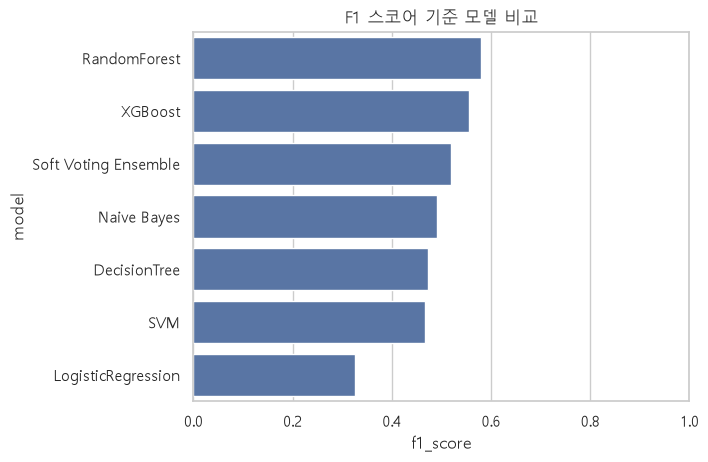

In [288]:
sns.barplot(data=df_model_result, x= 'f1_score',y= 'model')
plt.title('F1 스코어 기준 모델 비교')
plt.xlim(0, 1)
plt.show()

6. 클래스 불균형 문제
- 데이터 비율이 7:3 이라서 SMOTE 를 사용해서 비율을 맞춰주고 진행하면 성능개선 여지가 있다

In [ ]:
# 데이터 증강 기법 SMOTE
smote = SMOTE(random_state=SEED)

# 주의점 : 학습 데이터만 증강 적용해야 한다. (테스트 데이터에 적용하면 평가점수가 공정하게 되지 않음)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

print(f'증강된 X 데이터 수 : {X_train_over.shape[0]}, 증강된 y 데이터 수 :{y_train_over.shape[0]}')
print(pd.Series(y_train_over).value_counts())

증강된 X 데이터 수 : 1120, 증강된 y 데이터 수 :1120
Risk
1    560
0    560
Name: count, dtype: int64


In [291]:
xgb_over_model = XGBClassifier(random_state= SEED)
xgb_over_model.fit(X_train_over, y_train_over)

result = check_metrix(xgb_over_model, '증강된 데이터 XGBClassifier', X_train,X_test,y_train,y_test)

model_result.append(result)

증강된 데이터 XGBClassifier의 학습 정확도 : 1.0000
증강된 데이터 XGBClassifier의 학습 정밀도 : 1.0000
증강된 데이터 XGBClassifier의 학습 재현율 : 1.0000
증강된 데이터 XGBClassifier의 학습 F1스코어 : 1.0000
------------------------------------------------------------------------------------------
증강된 데이터 XGBClassifier의 학습 정확도 : 0.7050
증강된 데이터 XGBClassifier의 학습 정밀도 : 0.5085
증강된 데이터 XGBClassifier의 학습 재현율 : 0.5000
증강된 데이터 XGBClassifier의 학습 F1스코어 : 0.5042


In [296]:
model_result

[{'model': 'LogisticRegression',
  'accuracy': 0.73,
  'precision': 0.65,
  'recall': 0.21666666666666667,
  'f1_score': 0.325},
 {'model': 'Naive Bayes',
  'accuracy': 0.74,
  'precision': 0.5952380952380952,
  'recall': 0.4166666666666667,
  'f1_score': 0.49019607843137253},
 {'model': 'SVM',
  'accuracy': 0.76,
  'precision': 0.7,
  'recall': 0.35,
  'f1_score': 0.4666666666666667},
 {'model': 'DecisionTree',
  'accuracy': 0.7,
  'precision': 0.5,
  'recall': 0.45,
  'f1_score': 0.47368421052631576},
 {'model': 'RandomForest',
  'accuracy': 0.79,
  'precision': 0.725,
  'recall': 0.48333333333333334,
  'f1_score': 0.58},
 {'model': 'XGBoost',
  'accuracy': 0.745,
  'precision': 0.5818181818181818,
  'recall': 0.5333333333333333,
  'f1_score': 0.5565217391304348},
 {'model': 'Soft Voting Ensemble',
  'accuracy': 0.76,
  'precision': 0.65,
  'recall': 0.43333333333333335,
  'f1_score': 0.52},
 {'model': '증강된 데이터 XGBClassifier',
  'accuracy': 0.705,
  'precision': 0.5084745762711864,
 

실습 과제
1. 하이퍼 파라미터 튜닝 (Optuna, GridSearchCV, RandomizedSearchCV)
2. 증강한 데이터로 학습해보고 비교해보기
3. Pipeline과 ColumnTransformer 사용해서 전처리와 모델 학습을 하나로 묶어서 임의의 데이터로 테스트

고도화 실습 과제 
- 추론모델을 함수형으로 모듈화 시켜 streamlit 에서 입력받은 값으로 출력 진행해보기

In [302]:
import optuna
from optuna.samplers import TPESampler  # 이전의 실험 결과를 보고, 성능이 좋을 것같은 조합을 탐색하는 기법
from sklearn.model_selection import StratifiedKFold, cross_val_score 
from sklearn.tree import DecisionTreeClassifier

hyper_params = []

# Optuna 로그가 너무많이 출력되지 않도록 경고 메세지만 출력
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    #Optuna 가 한번에 trial 에서 사용할 하이퍼파라미터를 제안
    params = {
        'max_depth' : trial.suggest_int('max_depth',2,10),
        'min_samples_split' : trial.suggest_int('min_samples_split',2, 10),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf',1, 10),
        'criterion' :  trial.suggest_categorical('criterion', ['gini','entropy']),  # 노드 분리 기준(지니 불순도, 엔트로피)
        'random_state' : SEED
    }

    model = DecisionTreeClassifier(**params)
    
    # Risk 비율 fold 마다 비슷하게 유지되도록 StratifiedKFold 사용
    cv = StratifiedKFold(n_splits= 5, shuffle= True, random_state=SEED)
    
    # 5-fold 교차검증 정확도 계산
    scores = cross_val_score(model, X_train, y_train, cv= cv, scoring='accuracy')
    
    # 교차검증 정확도의 평균이 최대화 되는 방향으로 학습
    return scores.mean()


sampler = TPESampler(seed=SEED)
study = optuna.create_study(direction='maximize', sampler=sampler)

study.optimize(objective, n_trials= 100) # n_trials 가 증가되면 시간은 증가되지만, 더 많이 시도해서 탐색

print(f"Optuna의  최적의 하이퍼파라미터 :{study.best_params}")

print(f"Optuna의 최적의 정확도 :{study.best_value:.4f}")

Optuna의  최적의 하이퍼파라미터 :{'max_depth': 7, 'min_samples_split': 4, 'min_samples_leaf': 6, 'criterion': 'gini'}
Optuna의 최적의 정확도 :0.7388


DecisionTree
- Optuna의  최적의 하이퍼파라미터 :{'max_depth': 7, 'min_samples_split': 4, 'min_samples_leaf': 6, 'criterion': 'gini'}
- Optuna의 최적의 정확도 :0.7388


RandomForest
- Optuna의  최적의 하이퍼파라미터 :{'max_depth': 10, 'min_samples_split': 6, 'min_samples_leaf': 3, 'criterion': 'entropy'}
- Optuna의 최적의 정확도 :0.7450